# Deteksi Berita Palsu (Fake News) dengan Convolutional Neural Network (CNN)
Notebook ini berisi alur lengkap (pipeline) untuk mendeteksi berita palsu menggunakan metode CNN, mulai dari pemrosesan data, pembangunan model, hingga evaluasi akurasi.

## 1. Import Library
Mengimpor library yang dibutuhkan seperti Pandas, Numpy, Scikit-learn, TensorFlow/Keras, dan Sastrawi (untuk NLP bahasa Indonesia).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# Library untuk NLP Bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset
Memuat dataset berita. Dalam contoh ini, kita membuat dataset simulasi sederhana. Pada praktiknya, ganti bagian ini dengan `pd.read_csv('dataset.csv')` yang berisi kolom teks berita dan label (1 untuk Fake, 0 untuk Real).

In [4]:
import pandas as pd
import os

print("Membaca Dataset...")
# Menggunakan dataset Indonesian Fact and Hoax Political News
hoax_path = 'datasets/Indonesian Fact and Hoax Political News/Cleaned/dataset_turnbackhoax_10_cleaned.xlsx'
fakta_path = 'datasets/Indonesian Fact and Hoax Political News/Cleaned/dataset_cnn_10k_cleaned.xlsx'

# Membaca dataset (kita ambil 1000 data pertama dari masing-masing agar cepat diproses sebagai contoh)
df_hoax = pd.read_excel(hoax_path, nrows=1000)
df_fakta = pd.read_excel(fakta_path, nrows=1000)

# Pastikan label sesuai (1 untuk hoax, 0 untuk fakta)
df_hoax['label'] = 1
df_fakta['label'] = 0

# Menggabungkan kedua dataframe
df = pd.concat([df_hoax, df_fakta], ignore_index=True)

# Memilih kolom Teks (menggunakan 'Title' atau 'FullText'). Kita gunakan 'Title' untuk contoh yang lebih cepat,
# atau gabungan Title dan FullText jika tersedia.
df['text'] = df['Title'].fillna('') + " " + df['FullText'].fillna('')

# Mengacak urutan data (shuffle)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total Data:", len(df))
display(df[['text', 'label']].head())



Membaca Dataset...
Total Data: 2000


,text,label
0,Demokrat Pecat Wakil Ketua DPRD Solok Usai Ter...,0
1,[SALAH] Jus Daun Pepaya untuk Obat Demam Berda...,1
2,NasDem Jawab Sindiran Hasto Soal Wacana Pertem...,0
3,[SALAH] Surat Permintaan Data Pensiunan PNS da...,1
4,Golkar Sindir Intervensi Parpol Koalisi soal R...,0


## 3. Pemrosesan Data (Text Preprocessing)
Membersihkan teks dari tanda baca, angka, dan mengubahnya menjadi huruf kecil. Juga melakukan penghapusan stopword dan stemming menggunakan library Sastrawi.

In [5]:
stopword_factory = StopWordRemoverFactory()
stopword = stopword_factory.create_stop_word_remover()

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def clean_text(text):
    # Mengubah ke huruf kecil
    text = text.lower()
    # Menghapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Menghapus karakter selain huruf
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Menghapus extra whitespace
    text = text.strip()
    # Stopword removal
    text = stopword.remove(text)
    # Stemming (proses ini mungkin agak lama untuk dataset besar)
    text = stemmer.stem(text)
    return text

# Mengaplikasikan fungsi pembersihan teks
print("Sedang memproses teks (ini akan memakan waktu untuk corpus besar)...")
df['cleaned_text'] = df['text'].apply(clean_text)
print("Pemrosesan teks selesai!")
display(df[['text', 'cleaned_text', 'label']].head())

Sedang memproses teks (ini akan memakan waktu untuk corpus besar)...
Pemrosesan teks selesai!


,text,cleaned_text,label
0,Demokrat Pecat Wakil Ketua DPRD Solok Usai Ter...,demokrat pecat wakil ketua dprd solok usai jer...,0
1,[SALAH] Jus Daun Pepaya untuk Obat Demam Berda...,salah jus daun pepaya obat demam darah dengue ...,1
2,NasDem Jawab Sindiran Hasto Soal Wacana Pertem...,nasdem jawab sindir hasto soal wacana temu pal...,0
3,[SALAH] Surat Permintaan Data Pensiunan PNS da...,salah surat minta data pensiun pns asn kait pr...,1
4,Golkar Sindir Intervensi Parpol Koalisi soal R...,golkar sindir intervensi parpol koalisi soal r...,0


## 4. Tokenisasi dan Padding
Mengubah teks kata-kata yang sudah bersih menjadi urutan angka (vektor representasi) agar dapat diproses oleh algoritma Deep Learning. Padding digunakan untuk menyamakan panjang urutan ke panjang yang sama.

In [6]:
max_features = 5000  # Maksimal jumlah kata unik yang akan digunakan (vocabulary size)
max_length = 50      # Maksimal panjang kata per kalimat/berita untuk input CNN

tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(df['cleaned_text'])

vocab_size = len(tokenizer.word_index) + 1

# Mengubah teks ke sequences angka berdasarkan tokenizer
X_seq = tokenizer.texts_to_sequences(df['cleaned_text'])

# Padding untuk menyamakan panjang list ke 'max_length'
X_pad = pad_sequences(X_seq, maxlen=max_length, padding='post')

y = df['label'].values
print("Shape of Data Tensor:", X_pad.shape)
print("Shape of Label Tensor:", y.shape)

Shape of Data Tensor: (2000, 50)
Shape of Label Tensor: (2000,)


## 5. Membagi Dataset (Train / Test Split)
Membagi data secara proporsional menjadi set pelatihan (training set) sebesar 80% dan set pengujian (testing set) 20%.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)

print("Data Latih (Train):", X_train.shape)
print("Data Uji (Test):", X_test.shape)

Data Latih (Train): (1600, 50)
Data Uji (Test): (400, 50)


## 6. Membangun Model Convolutional Neural Network (CNN)
Arsitektur Model Deep Learning untuk NLP kali ini menggunakan:
- **Embedding Layer**: Mempelajari representasi vektor untuk setiap kata.
- **Conv1D Layer**: Menggunakan filter konvolusi 1D untuk mengekstraksi fitur pola lokal secara kontekstual di antar kata yang berdekatan.
- **GlobalMaxPooling1D Layer**: Menangkap sinyal/fitur paling kuat dari setiap filter map hasil dari Conv1D.
- **Dense Layer (Fully Connected)**: Menyimpulkan dan menganalisis fitur menjadi output.
- **Dropout Layer**: Mencegah overfitting dengan mematikan neuron secara acak.
- **Output Layer (Sigmoid)**: Menghasilkan nilai probabilitas (0 hingga 1) untuk klasifikasi biner.

In [13]:
from tensorflow.keras.layers import Input # Pastikan Input di-import

embedding_dim = 64

model = Sequential([
    Input(shape=(max_length,)), # <--- Tambahkan layer Input ini
    Embedding(input_dim=max_features, output_dim=embedding_dim), # Hapus input_length
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 46, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369,409 (1.41 MB)

 Trainable params: 369,409 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Melatih Model (Training)
Melatih model pada data latih dengan menggunakan validasi pada data uji setiap selesainya sebuah epoch.

In [14]:
epochs = 10
batch_size = 16

history = model.fit(
    X_train, y_train, 
    epochs=epochs, 
    batch_size=batch_size, 
    validation_data=(X_test, y_test)
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8481 - loss: 0.3680 - val_accuracy: 0.9925 - val_loss: 0.0210
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9962 - loss: 0.0122 - val_accuracy: 0.9950 - val_loss: 0.0132
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9950 - val_loss: 0.0130
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9950 - val_loss: 0.0113
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 9.6776e-04 - val_accuracy: 0.9950 - val_loss: 0.0125
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 4.1619e-04 - val_accuracy: 0.9950 - val_loss: 0.0121
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 2.0635e-04 - val_accuracy: 0.9950 - val_loss: 0.0117
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 1.7817e-04 - 

## 8. Evaluasi Model
Menampilkan visualisasi grafik history loss & accuracy, serta mencetak classification report dan confusion matrix.

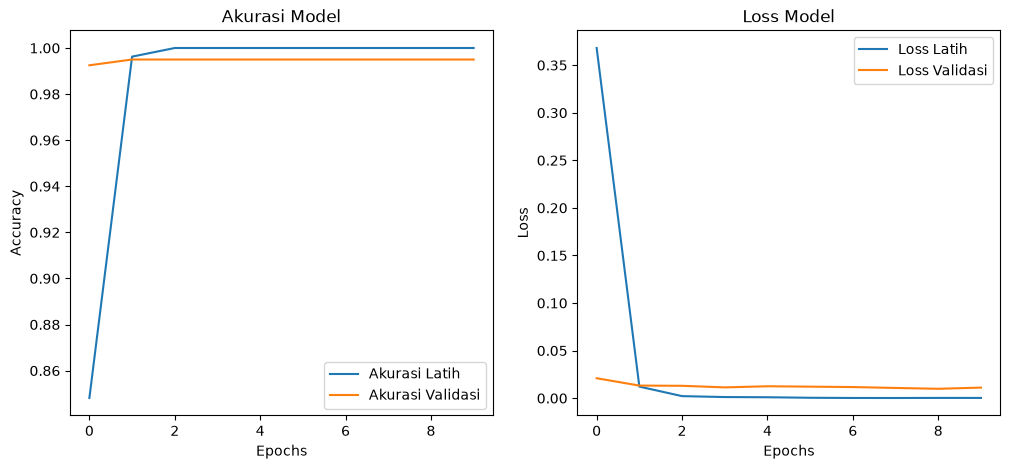

In [15]:
# Plotting Akurasi dan Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Akurasi Latih')
plt.plot(history.history['val_accuracy'], label='Akurasi Validasi')
plt.title('Akurasi Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss Latih')
plt.plot(history.history['val_loss'], label='Loss Validasi')
plt.title('Loss Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Akurasi Model: 99.50%

Classification Report:
                precision    recall  f1-score   support

Fakta/Real (0)       1.00      0.99      1.00       203
 Hoax/Fake (1)       0.99      1.00      0.99       197

      accuracy                           0.99       400
     macro avg       0.99      1.00      0.99       400
  weighted avg       1.00      0.99      1.00       400



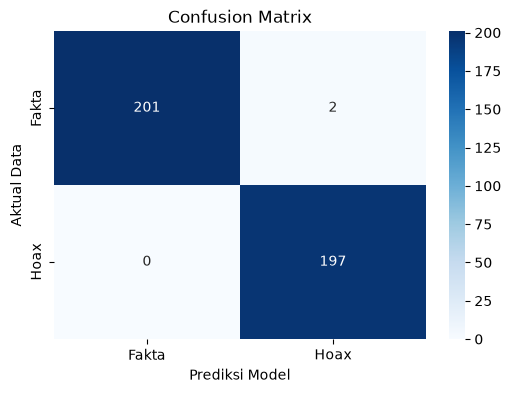

In [16]:
# Melakukan Prediksi pada data uji
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int) # Threshold 0.5

# Menghitung Akurasi Akhir
acc = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Model: {acc * 100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fakta/Real (0)', 'Hoax/Fake (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fakta', 'Hoax'], yticklabels=['Fakta', 'Hoax'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi Model')
plt.ylabel('Aktual Data')
plt.show()

## 9. Pengujian (Testing) Model pada Berita Baru
Membuat fungsi terpadu untuk menerima teks raw string dan memprediksinya.

In [17]:
def predict_news(news_text):
    print(f"Berita Masuk: {news_text}")
    
    # 1. Bersihkan teks
    cleaned = clean_text(news_text)
    
    # 2. Tokenisasi
    seq = tokenizer.texts_to_sequences([cleaned])
    
    # 3. Padding
    padded = pad_sequences(seq, maxlen=max_length, padding='post')
    
    # 4. Prediksi (Model Inference)
    prob = model.predict(padded)[0][0]
    
    label = "🚨 HOAX / FAKE NEWS" if prob > 0.5 else "✅ FAKTA / REAL NEWS"
    
    print(f"Prediksi: {label}")
    print(f"Probabilitas bahwa berita ini Hoax: {prob:.4f}\n")
    print("-" * 50)

# Coba prediksi beberapa teks
predict_news("Pemerintah memberikan subsidi bantuan uang tunai 10 juta via link berbahaya ini.")
predict_news("Kementerian Agama resmi menetapkan hari libur nasional untuk tanggal 17 Agustus tahun depan.")

Berita Masuk: Pemerintah memberikan subsidi bantuan uang tunai 10 juta via link berbahaya ini.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Prediksi: 🚨 HOAX / FAKE NEWS
Probabilitas bahwa berita ini Hoax: 0.7338

--------------------------------------------------
Berita Masuk: Kementerian Agama resmi menetapkan hari libur nasional untuk tanggal 17 Agustus tahun depan.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Prediksi: ✅ FAKTA / REAL NEWS
Probabilitas bahwa berita ini Hoax: 0.3770

--------------------------------------------------
